<!-- # LLM-101

Untill now we made good progress about the models (VAE, GAN, Diffusion...) that can approximate *continuous* distribution, usefull for images for example. But what about **Cathegorical Distributions** ?

A Categorical or Discrete distribution, governs how variability and randomness occurs over a *finite* set of realizations, the probability space is finite in this case (not like $\mathcal{R}$ where images live for example) examples : $\Omega $ can be {Head, Tail},{1,2,3,4,5} or {-1,1} ... , building such model for this case is a big deal inded, since many scenarios from our world are goverened by this type of distribution, the easiest example out there is **Text**.

<img src="docs/images/LLM/probs.png" width="700">


The way to see it is the following : imagine each word in our vocabulary a unique outcom, hence the overall set of possible items, is the whoole vocabulary that contains all the possible words. The model's job is to understand how each word interacts with 
all the others, and to learn all the underlying rules and concepts that governs our language, like the intervention of verbs that occurs usualy after a subject, and each sentence is finished with a period ".", and so on ...

why weren't LLMs present waay before, simply because text is very-difficult and complex distribution to capture for many reasons : 

- **Context-dependence.** Most words are highly ambiguous in isolation. 
  Take "right" in the following sentences : *'turn right'*, *'you are right'*, *'I have the right to express'*. The same applies to countless words — 
  *run, charge, match, bat* — and resolving the ambiguity requires 
  understanding the full surrounding context, sometimes many sentences back.

- **Combinatorial explosion.** the space of possible sequences is astronomical.
consider the **n-gram assumption**: the probability of the occurence of a word in the $i$-th position depends only on the $n$ words before it 

  $$P(w_i \mid sentence) \approx P(w_i \mid w_{i-1}, \ldots, w_{i-n})$$

  Even this drastic simplification is problematic. For a vocabulary of size
  $|\Omega| = 10^5$ words (still simplistic scenario) and $n = 5$, the number of possible n-grams to 
  store is $(10^5)^5 = 10^{25}$ — far beyond any conceivable memory or 
  compute budget. And $n = 5$ is already a naive approximation: in reality, 
  words depend on context from many sentences prior.

  That's approximately the number of atoms in the observable universe — and 
  we haven't even left the realm of short phrases.
 -->


# LLM-101

Until now, we have made good progress studying models (VAE, GAN, Diffusion...) that approximate *continuous* distributions, useful for images for example. But what about **categorical distributions**?

A categorical (or discrete) distribution governs how variability and randomness occur over a *finite* set of outcomes. The probability space is finite in this case (unlike $\mathbb{R}$, where images typically live). Examples:  
$\Omega = \{\text{Head, Tail}\}$, $\{1,2,3,4,5\}$, or $\{-1,1\}$.

Building models for such distributions is a big deal indeed, since many real-world scenarios are governed by this type of distribution. The most prominent example is **text**.

<p align="center">
  <img src="docs/images/LLM/probs.png" width="700">
</p>









The way to see it is the following: imagine each word in our vocabulary as a unique outcome. Then, the set of all possible outcomes is simply the entire vocabulary. The model’s job is to understand how words interact with one another, and to learn the underlying rules and structures that govern language—such as verbs typically following subjects, or sentences ending with a period ".", and so on.

Why weren’t LLMs present much earlier? Simply because text is a very difficult and complex distribution to model, for several reasons:

- **Context-dependence.**  
  Most words are highly ambiguous in isolation, many words can refer to many different meanings depending on their context.  
  Take the word *“right”* in the following sentences:  
  *“turn right”*, *“you are right”*, *“I have the right to express myself”*...  
  The same applies to countless words—*run, charge, match, bat*—and resolving this ambiguity requires understanding the surrounding context, sometimes many sentences back.

- **Combinatorial explosion.**  
  The space of possible sequences is astronomical.

  Consider the **n-gram assumption**: the probability of a word at position $i$ depends only on the previous $n$ words, mathematically, we must find for all words :

  $$
  P(w_i \mid \text{sentence}) = P(w_i \mid w_{i-1},w_{i-2} \ldots, w_{i-n})
  $$

  Even this drastic simplification is problematic. For a vocabulary of size  
  $Card(\Omega) = 100.000 $ words (English Vocabulary contains far more) and $n = 10 $, : that's $ (10^5)^10- (10^5)^9 \approx 10^{50} $ parameters to find and store somewhere, This is roughly on the order of the number of atoms in the earth, and we haven’t even left the realm of short phrases.

  And $ n = 8 $ is already a naive approximation: in reality, words depend on context that can span entire paragraphs or documents.

  This is roughly on the order of the number of atoms in the observable universe—and we haven’t even left the realm of short phrases.

# The Embeddings

One intelligent way to handle text is to represent each word as a vector in $\mathbb{R}^D$, where $D$ is the embedding dimension. This representation is called the **embedding** of a word.

Naturally, this representation should capture meaningful properties. We want embeddings to reflect similarity between words: for example, embeddings of animals should be close to each other, forming clusters, while opposing concepts should be oriented in opposite directions.

Such representations proved to be extremely powerful. Thanks this rich representation, complex tasks like document classification or semantic clustering becomes straightforward operations on vectors using simple Machine-Learning algorithms

<p align="center">
  <img src="docs/images/LLM/embed.png" width="700">
</p>

Many methods have been proposed, one of the most influential being **Word2Vec**. 
( *Below is a code that uses the embedding of word2vec to showcase the property above* )

> 💡 **Insight — Cosine similarity**
>
> The standard way to measure closeness between two embeddings is **cosine
> similarity** — the normalized dot product between two vectors:
>
> $$\cos(\theta) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \, \|\vec{v}\|}$$
>
> Geometrically, it measures the angle between two vectors regardless of
> their magnitude. A score of $+1$ means the vectors point in the same
> direction (synonyms), $0$ means orthogonal (unrelated), and $-1$ means
> opposite directions (ideally).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from sklearn.decomposition import PCA
# from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

# ! make sure to install gensim: the package that gives pretrained word2vec
import gensim.downloader as api

# loading the model
model = api.load("word2vec-google-news-300")
print("Model loaded. Vocabulary size:", len(model.key_to_index))

Loading Word2Vec pretrained vectors (Google News 300d) ...
First run downloads ~1.6GB — cached afterwards.

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model loaded. Vocabulary size: 3000000


In [ ]:
print("\n── 1. Nearest neighbours ──────────────────────────────────────────────")

words_to_probe = ["cat", "king", "france", "doctor", "happy"]
for word in words_to_probe:
    neighbours = model.most_similar(word, topn=6)
    print(f"\n  '{word}':")
    for neighbour, score in neighbours:
        print(f"    {neighbour:<20s}  cos={score:.3f}")



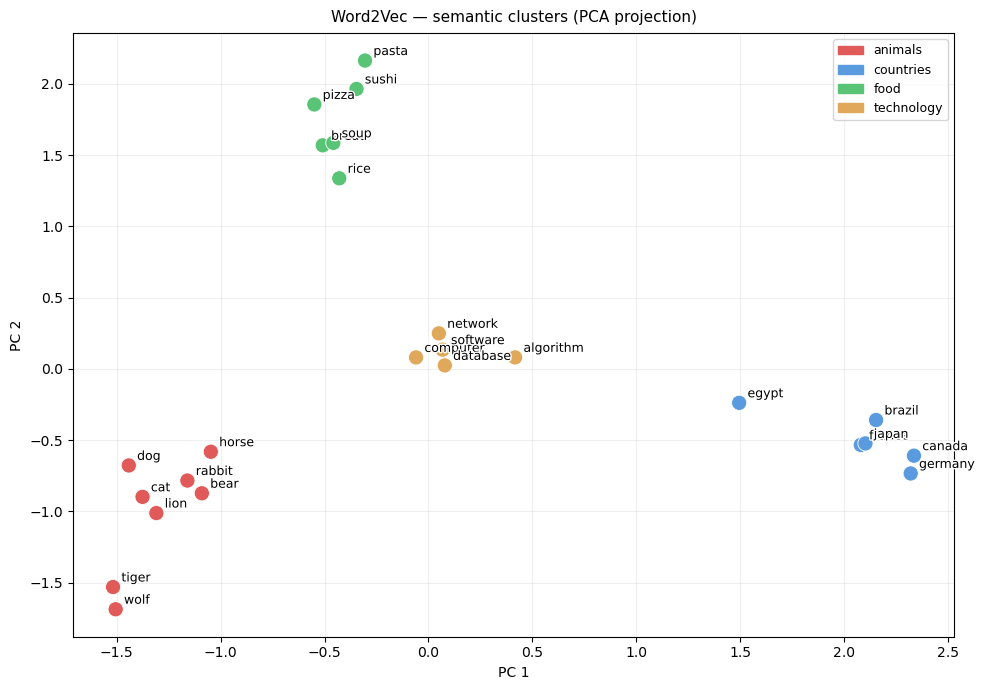

Saved: w2v_clusters.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4. VISUALISATION — PCA projections
# ═══════════════════════════════════════════════════════════════════════════════

def get_vectors(words):
    vecs  = np.array([model[w] for w in words if w in model])
    valid = [w for w in words        if w in model]
    return valid, vecs


# ── Helper: annotated scatter ────────────────────────────────────────────────
def scatter_words(ax, coords, words, colors, title, draw_arrows=None):
    """
    coords     : (N, 2) PCA-reduced vectors
    words      : list of word strings
    colors     : list of colour strings (one per word)
    draw_arrows: list of (i, j) index pairs to connect with an arrow
    """
    ax.scatter(coords[:, 0], coords[:, 1],
               c=colors, s=120, zorder=3, edgecolors="white", linewidths=0.6)

    for i, (word, (x, y)) in enumerate(zip(words, coords)):
        ax.annotate(
            word, (x, y),
            textcoords="offset points", xytext=(6, 4),
            fontsize=9, fontweight="500",
            path_effects=[pe.withStroke(linewidth=2, foreground="white")],
        )

    if draw_arrows:
        for i, j in draw_arrows:
            ax.annotate(
                "", xy=coords[j], xytext=coords[i],
                arrowprops=dict(arrowstyle="->", color="#555", lw=1.2),
            )

    ax.set_title(title, fontsize=11, pad=8)
    ax.grid(alpha=0.2)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")


# ── Fig 1 — Semantic clusters ─────────────────────────────────────────────────
animal_words  = ["cat", "dog", "horse", "rabbit", "wolf", "lion", "tiger", "bear"]
country_words = ["france", "germany", "japan", "brazil", "egypt", "canada"]
food_words    = ["pizza", "sushi", "bread", "rice", "pasta", "soup"]
tech_words    = ["computer", "software", "algorithm", "network", "database"]

all_words  = animal_words + country_words + food_words + tech_words
all_colors = (["#E05A5A"] * len(animal_words) +
              ["#5A9BE0"] * len(country_words) +
              ["#5AC476"] * len(food_words)    +
              ["#E0A85A"] * len(tech_words))

valid, vecs = get_vectors(all_words)
colors_valid = [all_colors[all_words.index(w)] for w in valid]

pca2  = PCA(n_components=2)
coords = pca2.fit_transform(vecs)

fig, ax = plt.subplots(figsize=(10, 7))
scatter_words(ax, coords, valid, colors_valid,
              "Word2Vec — semantic clusters (PCA projection)")

import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(color="#E05A5A", label="animals"),
    mpatches.Patch(color="#5A9BE0", label="countries"),
    mpatches.Patch(color="#5AC476", label="food"),
    mpatches.Patch(color="#E0A85A", label="technology"),
]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()


> 💡 **Insight:**  
> - The visualization above shows how similar words tend to live in the same neighborhood in the embedding space.
>
> - In practice, each word embedding is a **high-dimensional vector**. The 2D visualization is obtained by projecting these vectors down to 2 dimensions while preserving as much information as possible.
>
> - This is typically done using **PCA (Principal Component Analysis)**, a mathematical transformation used for **dimensionality reduction**. It finds new axes (principal components) along which the variance (information) of the data is maximized, and discards directions where information is redundant or negligible.


## Limitations & Transformers: 

- A subtle failure of Word2Vec: it cannot reliably distinguish
antonyms from synonyms. Because the model was trained in a way to capture the **co-occurrence patterns** and not the **meaning**, resulting for words like "Happy" and "sad" to score almost as high as happy and joyfull on cosine-similarity score.

- The biggest second failure is that these Embeddings are *static*, meaning that **every word has one fixed vector, forever, regardless of context.**. words like **mouse** *(animal / computer device)*, **apple** *(fruit / company)* would have wandering Embeddings without meaningfull representation.

Here comes fianlly the revolutianry Architecture that solved this problem, the backbone of all the LLMs and modern generative-modeling : the **Transformers**. they solved the problem by introducing a for each word a **dynamic Embedding**, that is recomputed every time based on its full surrounding context, using the **Attention** mechanism.

